# GNN Training for DNA Thermodynamics Prediction

This notebook builds a Graph Neural Network from scratch to predict DNA thermodynamic parameters (dH, Tm) from sequence and structure.

**Pipeline:**
1. Load & explore the dataset
2. Convert each DNA sequence+structure → graph
3. Define the GNN architecture
4. Train for 200 epochs (with wandb logging)
5. Plot training/validation errors
6. Save the model

## 1. Imports & Setup

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn.functional as F
from torch.nn import Linear, ModuleList
from torch_geometric.data import InMemoryDataset, Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import TransformerConv
from torch_geometric.nn.aggr import Set2Set

import wandb

# Monkey-patch for PyTorch 1.12 compatibility with torch_geometric
_original_torch_load = torch.load
def _patched_torch_load(*args, **kwargs):
    kwargs.pop('weights_only', None)
    return _original_torch_load(*args, **kwargs)
torch.load = _patched_torch_load

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__}, Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

PyTorch 1.12.1, Device: cuda:0
GPU: Tesla T4


## 2. Load & Explore the Dataset

The dataset is at `data/models/raw/combined_dataset.csv` with columns:
- `dataset`: source (`arr`=array, `uv`, `lit_uv`, `ov`)
- `SEQID`: unique identifier
- `RefSeq`: DNA sequence (e.g. `CAACCAGAAATGGTTG`)
- `TargetStruct`: dot-bracket structure (e.g. `((((((....))))))` for hairpin, `(((((+)))))` for duplex)
- `dH`, `Tm`, `dG_37`: thermodynamic parameters (targets)

We train on the `arr` subset. The `uv`, `lit_uv`, `ov` subsets are for external evaluation only.

In [2]:
# Load data
DATA_ROOT = './data/models'
RAW_DIR = os.path.join(DATA_ROOT, 'raw')

df = pd.read_csv(os.path.join(RAW_DIR, 'combined_dataset.csv'), index_col='SEQID')
df.sort_index(inplace=True)

with open(os.path.join(RAW_DIR, 'combined_data_split.json'), 'r') as f:
    split_dict = json.load(f)

print(f'Total records: {len(df)}')
print(f'\nDataset breakdown:')
print(df['dataset'].value_counts())
print(f'\nSplit sizes: train={len(split_dict["train_ind"])}, val={len(split_dict["val_ind"])}, test={len(split_dict["test_ind"])}')
print(f'\nSample rows:')
df.head(3)

Total records: 30872

Dataset breakdown:
arr       27730
ov         2775
lit_uv      348
uv           19
Name: dataset, dtype: int64

Split sizes: train=25025, val=2888, test=2958

Sample rows:


,dataset,RefSeq,TargetStruct,sodium,DNA_conc,dH,Tm,dG_37
SEQID,,,,,,,,
BC1,arr,CAACCAGAAATGGTTG,((((((....)))))),0.063,NaN,-29.405457,52.382626,-1.389517
BC10,arr,CAATCAGAAATGGTTG,(((.((....)).))),0.063,NaN,-13.860604,28.607763,0.385480
BC11,arr,CAAGCAGAAATGGTTG,(((.((....)).))),0.063,NaN,-19.310492,32.871813,0.260496


## 3. Convert Each Record to a Graph

Each DNA sequence+structure becomes a `torch_geometric.data.Data` object:

| Graph element | What it represents | Feature dim |
|---|---|---|
| **Node** | One nucleotide | 4 (one-hot: A, T, C, G) |
| **Edge** | Backbone bond or hydrogen bond | 3 (is_5to3, is_3to5, is_hbond) |
| **y (label)** | Thermodynamic params | 2 (normalized dH, Tm) |

Edges come from the dot-bracket notation:
- `.` = unpaired → only backbone edges to neighbors
- `(` matched with `)` → hydrogen bond edge between the pair
- `+` = strand break (duplex) → no backbone edge across it

In [1]:
# ---- Feature encoding functions ----

def onehot_nucleotide(seq_str: str) -> np.ndarray:
    """One-hot encode a DNA sequence. Returns (N, 4) array."""
    mapping = {'A': 0, 'T': 1, 'C': 2, 'G': 3}
    N = len(seq_str)
    arr = np.zeros((N, 4), dtype=np.float32)
    for i, nt in enumerate(seq_str.upper()):
        arr[i, mapping[nt]] = 1.0
    return arr


def dotbracket_to_edges(struct: str):
    """
    Convert dot-bracket notation to edge list + edge features.
    
    Returns:
        edge_index: (2, num_edges) tensor
        edge_attr: (num_edges, 3) tensor - [is_5to3, is_3to5, is_hbond]
    """
    N = len(struct)
    strand_break = struct.find('+')
    
    if strand_break == -1:
        # Hairpin: backbone connects all consecutive nucleotides
        backbone = [[i, i+1] for i in range(N - 1)]
    else:
        # Duplex: remove '+' and skip the break position
        struct = struct.replace('+', '')
        N -= 1
        backbone = [[i, i+1] for i in range(N - 1)
                    if i != strand_break - 1 and i + 1 != strand_break]
    
    # Find hydrogen bonds from matched parentheses
    hbonds = []
    flag3p = N - 1
    for i, ch in enumerate(struct):
        if ch == '(':
            for j in range(flag3p, i, -1):
                if struct[j] == ')':
                    hbonds.append([i, j])
                    flag3p = j - 1
                    break
    
    # Build full edge list: 5'→3', 3'→5', hbond (both directions)
    print(f"Backbone {backbone}\nBackbone reversed {[e[::-1] for e in backbone]}\nHbond {hbonds}\nHbonds rev {[e[::-1] for e in hbonds]}")
    print(f"shape of each\nBackbone {torch.tensor(backbone).shape}\nHbond {torch.tensor(hbonds).shape}")
    edges = (backbone + 
             [e[::-1] for e in backbone] + 
             hbonds + 
             [e[::-1] for e in hbonds])
    
    n_bb, n_hb = len(backbone), len(hbonds)
    edge_attr = np.zeros((len(edges), 3), dtype=np.float32)
    edge_attr[:n_bb, 0] = 1           # 5' → 3'
    edge_attr[n_bb:2*n_bb, 1] = 1     # 3' → 5'
    edge_attr[2*n_bb:, 2] = 1         # hydrogen bonds
    
    edge_index = torch.tensor(np.array(edges).T, dtype=torch.long)
    edge_attr = torch.tensor(edge_attr, dtype=torch.float)
    
    return edge_index, edge_attr


# Quick sanity check
ei, ea = dotbracket_to_edges('((..))')
print(f'Structure "((..))": {ei.shape[1]} edges, {ea.shape}')
print(f'One-hot "ATCG":\n{onehot_nucleotide("ATCGATGC")}')

NameError: name 'np' is not defined

In [5]:
# ---- Normalization (min-max using training set stats) ----

def calc_sumstats(df):
    """Compute min/max for dH and Tm from a dataframe."""
    return {
        'dH_min': np.nanmin(df.dH), 'dH_max': np.nanmax(df.dH),
        'Tm_min': np.nanmin(df.Tm), 'Tm_max': np.nanmax(df.Tm),
    }

def normalize(val, vmin, vmax):
    return (val - vmin) / (vmax - vmin)

def unnormalize(val, vmin, vmax):
    return val * (vmax - vmin) + vmin

# Compute stats from TRAINING set only
train_df = df.loc[df.index.isin(split_dict['train_ind'])]
stats = calc_sumstats(train_df)
print('Training set normalization stats:')
stats

Training set normalization stats:


{'dH_min': -68.20454632608892,
 'dH_max': -2.70243642577065,
 'Tm_min': 13.647488646379209,
 'Tm_max': 68.63588396988382}

In [ ]:
# ---- Convert one row to a graph Data object ----

def row_to_graph(row, stats):
    """
    Convert a single dataframe row into a torch_geometric Data object.
    
    Args:
        row: pandas Series with RefSeq, TargetStruct, dH, Tm
        stats: dict with dH_min, dH_max, Tm_min, Tm_max
    Returns:
        Data(x, edge_index, edge_attr, y)
    """
    # Parse RefSeq (handle string-repr lists for duplex)
    refseq = row['RefSeq']
    
    # if refseq = ['abc', 'abc']
    if isinstance(refseq, list):
        refseq = ''.join(refseq)
        
    # if refseq = "['abc', abc]"
    
    elif isinstance(refseq, str) and '[' in refseq:
        refseq = ''.join(eval(refseq))
    
    # Node features: one-hot nucleotides
    x = torch.tensor(onehot_nucleotide(refseq), dtype=torch.float)
    
    # Edge features: from dot-bracket structure
    edge_index, edge_attr = dotbracket_to_edges(row['TargetStruct'])
    
    # Labels: normalized dH and Tm
    dH_norm = normalize(row['dH'], stats['dH_min'], stats['dH_max'])
    Tm_norm = normalize(row['Tm'], stats['Tm_min'], stats['Tm_max'])
    y = torch.tensor([dH_norm, Tm_norm], dtype=torch.float)
    
    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)

# Test with one sample
sample = df.iloc[0]
g = row_to_graph(sample, stats)
print(f'Sample graph: {g.num_nodes} nodes, {g.num_edges} edges, y={g.y}')

Sample graph: 16 nodes, 42 edges, y=tensor([0.5923, 0.7044])


## 4. Build the Dataset & DataLoaders

We use `InMemoryDataset` so all graphs are processed once, saved to disk as `.pt`, and loaded instantly on subsequent runs.

In [7]:
class NNNGraphDataset(InMemoryDataset):
    """
    Converts combined_dataset.csv into a graph dataset.
    Processes once, then loads from disk.
    """
    def __init__(self, root, transform=None):
        super().__init__(root, transform)
        self.data, self.slices = torch.load(self.processed_paths[0])
        
        # Load metadata
        self.df = pd.read_csv(os.path.join(self.raw_dir, 'combined_dataset.csv'), index_col='SEQID')
        self.df.sort_index(inplace=True)
        
        with open(os.path.join(self.raw_dir, 'combined_data_split.json')) as f:
            self.split_dict = json.load(f)
        
        self.stats = calc_sumstats(self.df.loc[self.df.index.isin(self.split_dict['train_ind'])])
    
    @property
    def raw_file_names(self):
        return ['combined_dataset.csv', 'combined_data_split.json']
    
    @property
    def processed_file_names(self):
        return ['my_gnn_data.pt']  # Different name so it won't conflict with original
    
    def process(self):
        """Convert every row in CSV to a graph and save."""
        print('Processing dataset (one-time)...')
        df = pd.read_csv(os.path.join(self.raw_dir, 'combined_dataset.csv'), index_col='SEQID')
        df.sort_index(inplace=True)
        
        with open(os.path.join(self.raw_dir, 'combined_data_split.json')) as f:
            split_dict = json.load(f)
        
        train_stats = calc_sumstats(df.loc[df.index.isin(split_dict['train_ind'])])
        
        data_list = []
        for _, row in df.iterrows():
            data_list.append(row_to_graph(row, train_stats))
        
        data, slices = self.collate(data_list)
        torch.save((data, slices), self.processed_paths[0])
        print(f'Saved {len(data_list)} graphs.')
    
    def get_split(self, split='train', dataset_name='arr'):
        """Get indices for a specific split and dataset subset."""
        seqids = self.df.index
        split_ids = self.split_dict[split + '_ind']
        split_positions = np.searchsorted(seqids, split_ids)
        
        if dataset_name is not None:
            dataset_mask = (self.df['dataset'] == dataset_name).values
            dataset_positions = set(np.where(dataset_mask)[0])
            positions = sorted(set(split_positions) & dataset_positions)
        else:
            positions = sorted(split_positions)
        
        return self.index_select(positions)

# Build dataset
dataset = NNNGraphDataset(root=DATA_ROOT)
print(f'Total graphs: {len(dataset)}')
print(f'Stats: {dataset.stats}')

Processing...


Processing dataset (one-time)...
Saved 30872 graphs.
Total graphs: 30872
Stats: {'dH_min': -68.20454632608892, 'dH_max': -2.70243642577065, 'Tm_min': 13.647488646379209, 'Tm_max': 68.63588396988382}


Done!


In [8]:
# ---- Create DataLoaders ----

BATCH_SIZE = 1842  # Same as original paper
has_gpu = torch.cuda.is_available()

train_data = dataset.get_split('train', 'arr')
val_data   = dataset.get_split('val',   'arr')
test_data  = dataset.get_split('test',  'arr')

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, pin_memory=has_gpu)
val_loader   = DataLoader(val_data,   batch_size=BATCH_SIZE, shuffle=False, pin_memory=has_gpu)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False, pin_memory=has_gpu)

print(f'Train: {len(train_data)} graphs, {len(train_loader)} batches')
print(f'Val:   {len(val_data)} graphs, {len(val_loader)} batches')
print(f'Test:  {len(test_data)} graphs, {len(test_loader)} batches')

# Peek at one batch
batch = next(iter(train_loader))
print(f'\nBatch: {batch}')
print(f'  x shape: {batch.x.shape}')
print(f'  edge_index shape: {batch.edge_index.shape}')
print(f'  edge_attr shape: {batch.edge_attr.shape}')
print(f'  y shape: {batch.y.shape}')
print(f'  batch vector shape: {batch.batch.shape}')

Train: 25025 graphs, 14 batches
Val:   1318 graphs, 1 batches
Test:  1387 graphs, 1 batches

Batch: DataBatch(x=[31726, 4], edge_index=[2, 81236], edge_attr=[81236, 3], y=[3684], batch=[31726], ptr=[1843])
  x shape: torch.Size([31726, 4])
  edge_index shape: torch.Size([2, 81236])
  edge_attr shape: torch.Size([81236, 3])
  y shape: torch.Size([3684])
  batch vector shape: torch.Size([31726])


## 5. Define the GNN

Architecture (same as original paper):

```
Input: (num_nodes, 4) node features + (num_edges, 3) edge features
  │
  ├─ TransformerConv(4 → 125)  + LeakyReLU + Dropout
  ├─ TransformerConv(125 → 125) + LeakyReLU + Dropout  (×3 more)
  │
  ├─ Set2Set pooling (125 → 250)   ← graph-level readout
  │
  ├─ Linear(250 → 128) + ReLU + Dropout
  └─ Linear(128 → 2)               ← output: [dH_norm, Tm_norm]
```

In [ ]:
class GNN(torch.nn.Module):
    def __init__(self, 
                 hidden_channels=125,
                 n_conv_layers=4,
                 linear_hidden=128,
                 conv_dropout=0.0127,
                 linear_dropout=0.25,
                 set2set_steps=10):
        super().__init__()
        torch.manual_seed(12345)
        
        self.conv_dropout = conv_dropout
        self.linear_dropout = linear_dropout
        
        # Layer 1 Definition 
        # Graph convolution layers (TransformerConv)
        self.convs = ModuleList()
        # First layer: 4 input features → hidden_channels
        self.convs.append(
            TransformerConv(4, hidden_channels, heads=1, 
                           edge_dim=3, dropout=conv_dropout)
        )
        # Layer 1 Defined

        # Remaining layers: hidden → hidden

        # Layer 2, 3, 4 Defined using for loop
        for _ in range(n_conv_layers - 1):
            self.convs.append(
                TransformerConv(hidden_channels, hidden_channels, heads=1,
                               edge_dim=3, dropout=conv_dropout)
            )
        
        # Pooling: Set2Set (learnable graph-level aggregation)
        # Output dim = 2 * hidden_channels
        self.pool = Set2Set(hidden_channels, processing_steps=set2set_steps)
        
        # MLP head
        self.lin1 = Linear(2 * hidden_channels, linear_hidden)
        self.lin2 = Linear(linear_hidden, linear_hidden)  # Intermediate layer
        self.lin3 = Linear(linear_hidden, 2)  # 2 outputs: dH, Tm
    
    def forward(self, x, edge_index, edge_attr, batch):
        # 1. Graph convolutions
        for conv in self.convs:
            x = conv(x, edge_index, edge_attr)
            x = F.leaky_relu(x)
            x = F.dropout(x, p=self.conv_dropout, training=self.training)
        
        # 2. Pool nodes → single graph-level vector
        x = self.pool(x, batch)
        
        # 3. MLP prediction head
        x = self.lin1(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.linear_dropout, training=self.training)
        x = self.lin2(x)
        x = F.relu(x)
        x = self.lin3(x)
        x = F.relu(x)  # Ensure non-negative outputs (since dH and Tm are positive)
        
        return torch.flatten(x)

# Instantiate & count parameters
model = GNN().to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f'Model has {n_params:,} parameters')
print(model)

Model has 493,773 parameters
GNN(
  (convs): ModuleList(
    (0): TransformerConv(4, 125, heads=1)
    (1): TransformerConv(125, 125, heads=1)
    (2): TransformerConv(125, 125, heads=1)
    (3): TransformerConv(125, 125, heads=1)
    (4): TransformerConv(125, 125, heads=1)
  )
  (pool): Set2Set(125, 250)
  (lin1): Linear(in_features=250, out_features=128, bias=True)
  (lin2): Linear(in_features=128, out_features=128, bias=True)
  (lin3): Linear(in_features=128, out_features=2, bias=True)
)


## 6. Training Loop

For each epoch:
1. **Forward pass**: feed batch of graphs through the GNN
2. **Loss**: MSE between predicted and true (normalized) dH & Tm
3. **Backward pass**: compute gradients via `loss.backward()`
4. **Optimizer step**: update weights

Every 10 epochs, evaluate on the validation set and log to wandb.

In [20]:
# ---- Helper: compute RMSE over a loader (in normalized space) ----

@torch.no_grad()
def compute_rmse(model, loader):
    """Compute RMSE in normalized space."""
    model.eval()
    total_se = 0.0
    n = len(loader.dataset)
    for data in loader:
        out = model(data.x.to(device), data.edge_index.to(device),
                    data.edge_attr.to(device), data.batch.to(device))
        total_se += float(((out - data.y.to(device)) ** 2).sum())
    return np.sqrt(total_se / n)

In [21]:
# ---- Training config ----

CONFIG = dict(
    n_epoch=200,
    learning_rate=0.002379,
    batch_size=BATCH_SIZE,
    hidden_channels=125,
    n_conv_layers=4,
    linear_hidden=128,
    conv_dropout=0.0127,
    linear_dropout=0.25,
    set2set_steps=10,
    architecture='GraphTransformer',
    dataset='NNN_v2',
)

# Initialize wandb
run = wandb.init(project='NNN_GNN', config=CONFIG)
print(f'wandb run: {run.name}')

train_rmse,█▆▄▃▂▂▂▂▂▁▂▂▁▁▁▁▁▁▁▁
val_rmse,█▆▃▃▂▂▂▂▁▁▂▂▁▁▁▁▁▁▁▁
Tm_mae,3.44459
Tm_mae_adj,2.7264
Tm_r2,0.83774
Tm_rmse,4.35469
dG_37_mae,0.25352
dG_37_mae_adj,0.23711
dG_37_r2,0.87017
dG_37_rmse,0.37223
dH_mae,3.58357


wandb run: happy-elevator-15


In [22]:
# ---- Training loop ----

criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG['learning_rate'])

# Track metrics for plotting
history = {'epoch': [], 'train_rmse': [], 'val_rmse': []}

LOG_EVERY = 10  # Evaluate every N epochs

for epoch in range(CONFIG['n_epoch']):
    
    # --- Train one epoch ---
    model.train()
    for data in train_loader:
        # Forward pass
        out = model(data.x.to(device), data.edge_index.to(device),
                    data.edge_attr.to(device), data.batch.to(device))
        
        # Compute loss
        loss = criterion(out, data.y.to(device))
        
        # Backward pass + optimize
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
    
    # --- Evaluate every LOG_EVERY epochs ---
    if epoch % LOG_EVERY == 0:
        train_rmse = compute_rmse(model, train_loader)
        val_rmse = compute_rmse(model, val_loader)
        
        history['epoch'].append(epoch)
        history['train_rmse'].append(train_rmse)
        history['val_rmse'].append(val_rmse)
        
        wandb.log({'train_rmse': train_rmse, 'val_rmse': val_rmse}, step=epoch)
        print(f'Epoch {epoch:03d} | Train RMSE: {train_rmse:.4f} | Val RMSE: {val_rmse:.4f}')

print('\nTraining complete!')

Epoch 000 | Train RMSE: 0.2942 | Val RMSE: 0.2952
Epoch 010 | Train RMSE: 0.1719 | Val RMSE: 0.1743
Epoch 020 | Train RMSE: 0.1518 | Val RMSE: 0.1546
Epoch 030 | Train RMSE: 0.1419 | Val RMSE: 0.1443
Epoch 040 | Train RMSE: 0.1214 | Val RMSE: 0.1248
Epoch 050 | Train RMSE: 0.1192 | Val RMSE: 0.1237
Epoch 060 | Train RMSE: 0.1153 | Val RMSE: 0.1205
Epoch 070 | Train RMSE: 0.1059 | Val RMSE: 0.1125
Epoch 080 | Train RMSE: 0.0975 | Val RMSE: 0.1056
Epoch 090 | Train RMSE: 0.1086 | Val RMSE: 0.1162
Epoch 100 | Train RMSE: 0.1069 | Val RMSE: 0.1152
Epoch 110 | Train RMSE: 0.1066 | Val RMSE: 0.1156
Epoch 120 | Train RMSE: 0.1040 | Val RMSE: 0.1135
Epoch 130 | Train RMSE: 0.0997 | Val RMSE: 0.1101
Epoch 140 | Train RMSE: 0.0990 | Val RMSE: 0.1100
Epoch 150 | Train RMSE: 0.1051 | Val RMSE: 0.1159
Epoch 160 | Train RMSE: 0.0968 | Val RMSE: 0.1093
Epoch 170 | Train RMSE: 0.0935 | Val RMSE: 0.1064
Epoch 180 | Train RMSE: 0.0984 | Val RMSE: 0.1116
Epoch 190 | Train RMSE: 0.0964 | Val RMSE: 0.1104


## 7. Evaluate & Plot Results

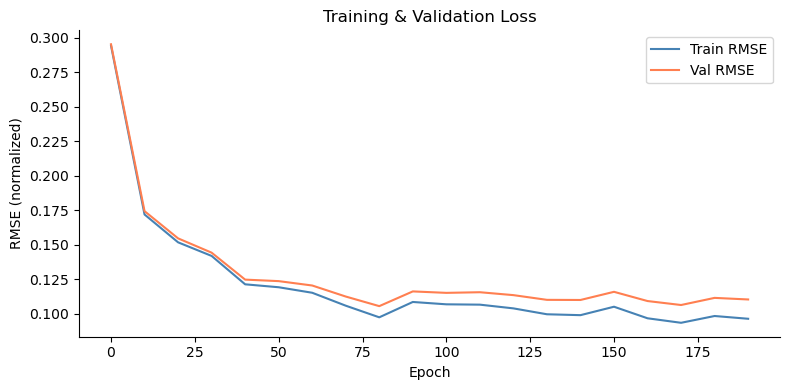

In [23]:
# ---- Plot training curves ----

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.plot(history['epoch'], history['train_rmse'], label='Train RMSE', color='steelblue')
ax.plot(history['epoch'], history['val_rmse'], label='Val RMSE', color='coral')
ax.set_xlabel('Epoch')
ax.set_ylabel('RMSE (normalized)')
ax.set_title('Training & Validation Loss')
ax.legend()
sns.despine()
plt.tight_layout()
wandb.log({'loss_curves': wandb.Image(fig)})
plt.show()

In [24]:
# ---- Get predictions in ORIGINAL (unnormalized) scale ----

@torch.no_grad()
def get_predictions(model, loader, stats):
    """Run model on a loader and return truth/pred arrays in original scale."""
    model.eval()
    y_all, pred_all = [], []
    
    for data in loader:
        out = model(data.x.to(device), data.edge_index.to(device),
                    data.edge_attr.to(device), data.batch.to(device))
        y_all.append(data.y.numpy().reshape(-1, 2))
        pred_all.append(out.cpu().numpy().reshape(-1, 2))
    
    y = np.concatenate(y_all)
    pred = np.concatenate(pred_all)
    
    # Unnormalize
    y[:, 0] = unnormalize(y[:, 0], stats['dH_min'], stats['dH_max'])
    y[:, 1] = unnormalize(y[:, 1], stats['Tm_min'], stats['Tm_max'])
    pred[:, 0] = unnormalize(pred[:, 0], stats['dH_min'], stats['dH_max'])
    pred[:, 1] = unnormalize(pred[:, 1], stats['Tm_min'], stats['Tm_max'])
    
    return y, pred


def calc_dG37(dH, Tm):
    """Calculate dG at 37°C from dH (kcal/mol) and Tm (°C)."""
    return dH * (1 - (273.15 + 37) / (273.15 + Tm))


train_y, train_pred = get_predictions(model, train_loader, dataset.stats)
val_y, val_pred = get_predictions(model, val_loader, dataset.stats)

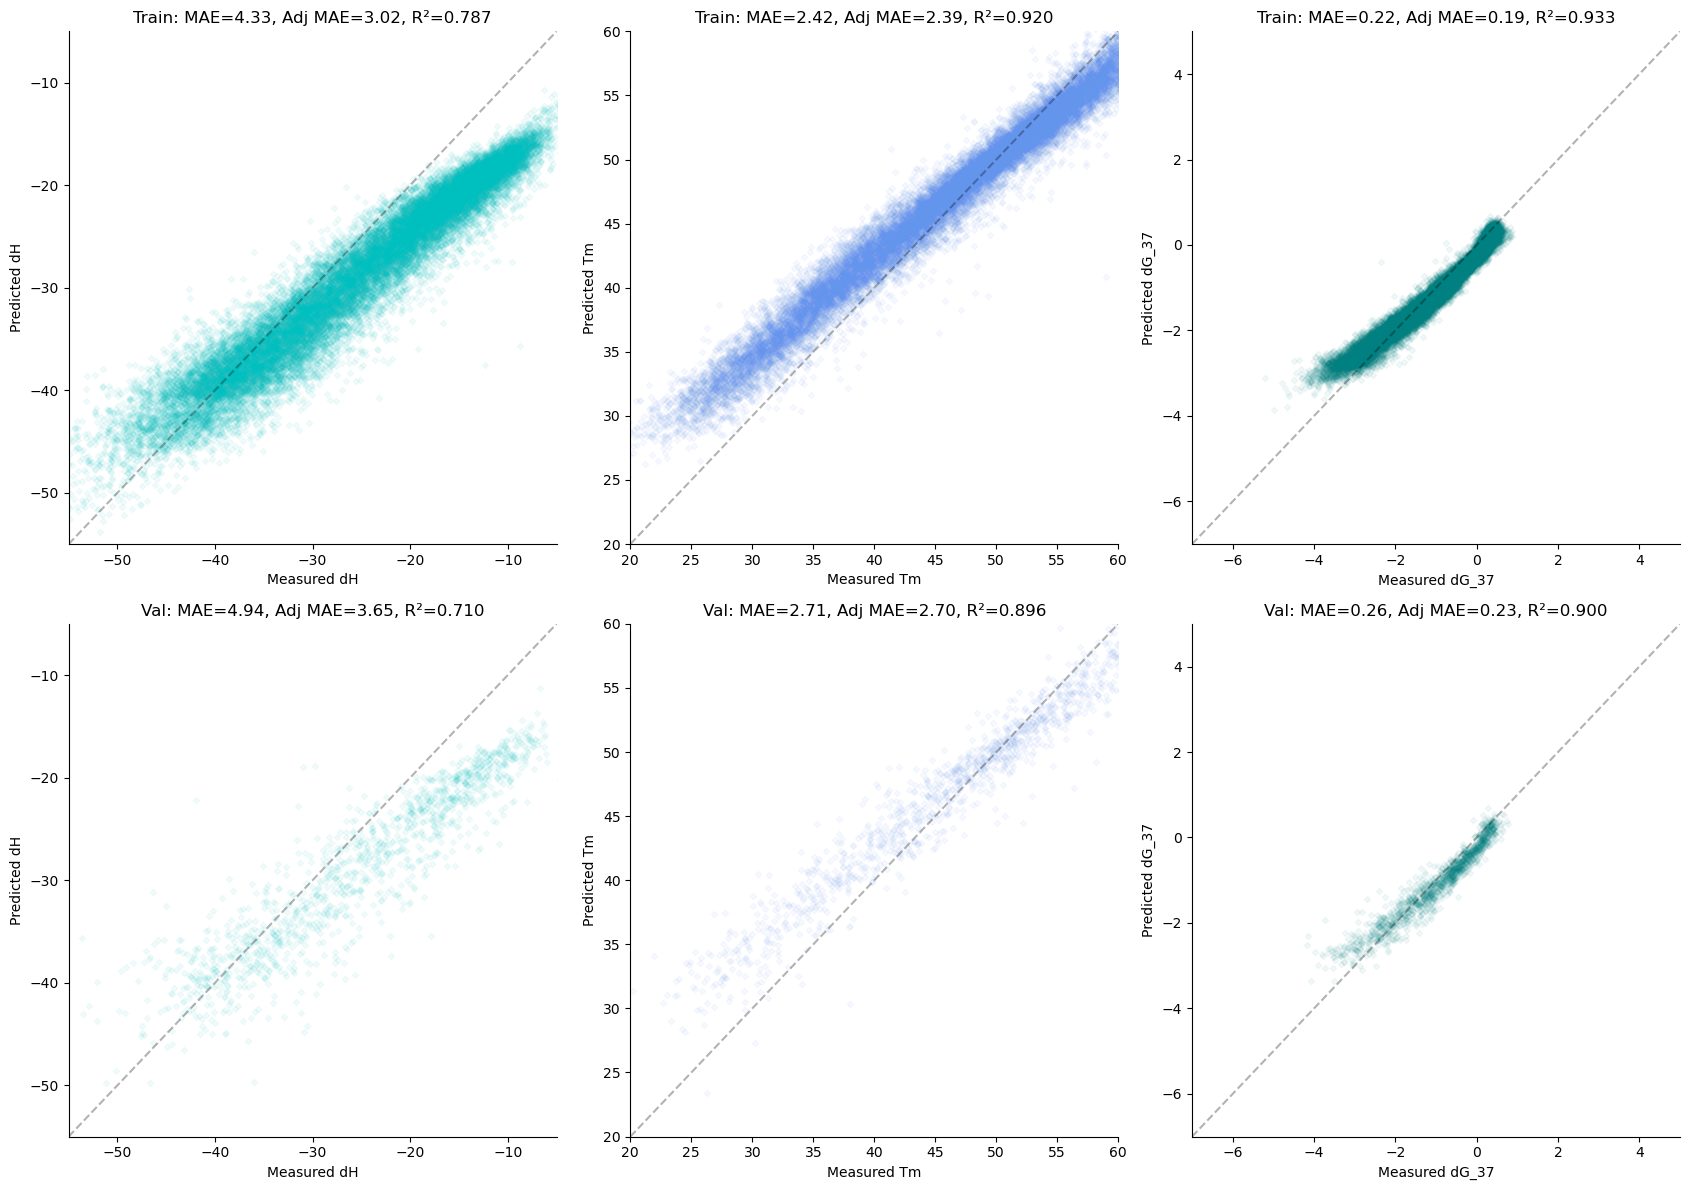


                     Validation Results                     
Metric            MAE    Adj MAE     RMSE       R²     Bias
------------------------------------------------------------
dH             4.9446     3.6509   5.9346   0.7104  -3.5297
Tm             2.7131     2.6981   3.4946   0.8955   0.4752
dG_37          0.2562     0.2348   0.3259   0.9005  -0.0742


In [25]:
# ---- Truth vs Predicted scatter plots ----
from sklearn.metrics import r2_score

def plot_scatter(y, pred, ax, param_name, title, color, lim):
    """Plot measured vs predicted scatter with MAE, Adjusted MAE, R²."""
    mask = ~np.isnan(y)
    y, pred = y[mask], pred[mask]
    
    rmse = np.sqrt(np.mean((y - pred)**2))
    mae = np.mean(np.abs(y - pred))
    r2 = r2_score(y, pred)
    
    # Adjusted MAE: remove mean bias, then compute MAE
    bias = np.mean(pred) - np.mean(y)
    pred_adj = pred - bias
    mae_adj = np.mean(np.abs(y - pred_adj))
    
    ax.scatter(y, pred, c=color, marker='D', alpha=0.05, s=10)
    ax.plot(lim, lim, 'k--', alpha=0.3)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel(f'Measured {param_name}')
    ax.set_ylabel(f'Predicted {param_name}')
    ax.set_title(f'{title}: MAE={mae:.2f}, Adj MAE={mae_adj:.2f}, R²={r2:.3f}')
    return dict(rmse=rmse, mae=mae, mae_adj=mae_adj, r2=r2, bias=bias)


fig, axes = plt.subplots(2, 3, figsize=(17, 12))

# Train plots
plot_scatter(train_y[:, 0], train_pred[:, 0], axes[0, 0], 'dH', 'Train', 'c', [-55, -5])
plot_scatter(train_y[:, 1], train_pred[:, 1], axes[0, 1], 'Tm', 'Train', 'cornflowerblue', [20, 60])
train_dG = calc_dG37(train_y[:, 0], train_y[:, 1])
train_dG_pred = calc_dG37(train_pred[:, 0], train_pred[:, 1])
plot_scatter(train_dG, train_dG_pred, axes[0, 2], 'dG_37', 'Train', 'teal', [-7, 5])

# Validation plots
dH_metrics = plot_scatter(val_y[:, 0], val_pred[:, 0], axes[1, 0], 'dH', 'Val', 'c', [-55, -5])
Tm_metrics = plot_scatter(val_y[:, 1], val_pred[:, 1], axes[1, 1], 'Tm', 'Val', 'cornflowerblue', [20, 60])
val_dG = calc_dG37(val_y[:, 0], val_y[:, 1])
val_dG_pred = calc_dG37(val_pred[:, 0], val_pred[:, 1])
dG_metrics = plot_scatter(val_dG, val_dG_pred, axes[1, 2], 'dG_37', 'Val', 'teal', [-7, 5])

sns.despine()
plt.tight_layout()
wandb.log({'results': wandb.Image(fig)})
plt.show()

# Print all metrics
print(f'\n{"="*60}')
print(f'{"Validation Results":^60}')
print(f'{"="*60}')
print(f'{"Metric":<12} {"MAE":>8} {"Adj MAE":>10} {"RMSE":>8} {"R²":>8} {"Bias":>8}')
print(f'{"-"*60}')
for name, m in [('dH', dH_metrics), ('Tm', Tm_metrics), ('dG_37', dG_metrics)]:
    print(f'{name:<12} {m["mae"]:>8.4f} {m["mae_adj"]:>10.4f} {m["rmse"]:>8.4f} {m["r2"]:>8.4f} {m["bias"]:>8.4f}')
print(f'{"="*60}')

# Log to wandb
wandb.run.summary.update({
    'dH_mae': dH_metrics['mae'], 'dH_mae_adj': dH_metrics['mae_adj'], 'dH_r2': dH_metrics['r2'], 'dH_rmse': dH_metrics['rmse'],
    'Tm_mae': Tm_metrics['mae'], 'Tm_mae_adj': Tm_metrics['mae_adj'], 'Tm_r2': Tm_metrics['r2'], 'Tm_rmse': Tm_metrics['rmse'],
    'dG_37_mae': dG_metrics['mae'], 'dG_37_mae_adj': dG_metrics['mae_adj'], 'dG_37_r2': dG_metrics['r2'], 'dG_37_rmse': dG_metrics['rmse'],
    'n_parameters': n_params,
})

## 8. Save the Model

In [ ]:
# Save model
os.makedirs('./models', exist_ok=True)
model_path = f'./models/gnn_{run.name}.pt'
torch.save(model.state_dict(), model_path)
print(f'Model saved to {model_path}')

# Also save normalization stats (needed to convert predictions back)
import json
with open(f'./models/gnn_{run.name}_stats.json', 'w') as f:
    json.dump(dataset.stats, f)

# Finish wandb run
wandb.finish()
print('Done!')